In [43]:
from collections import deque
from dataclasses import dataclass

from mesa import Agent, Model

from mesa.space import SingleGrid

from mesa.datacollection import DataCollector

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

import numpy as np
import pandas as pd

import heapq #se usa una cola de prioridad para implementar el algoritmo A*

In [44]:
#Clase para representar los estados de las paredes de una celda
@dataclass
class CellWalls:
    #Estado de las 4 paredes de una celda: 2 = intacta, 1 = dañada, 0 = destruida/inexistente
    up: int = 0
    down: int = 0
    left: int = 0
    right: int = 0

#Clase para representar el estado de las posibles puertas de una celda (ocupan el mismo borde que una pared)
@dataclass
class CellDoors:
    #Estado de las 4 puertas de una celda: 2 = cerrada, 1 = abierta, 0 = destruida/inexistente
    up: int = 0
    down: int = 0
    left: int = 0
    right: int = 0

#Clase especializda para crear y modificar estado de paredes y puertas (entorno)
class EnvironmentManager(Model):
    #Guardar dirección opuesta para sincronizar daños con la celda que comparte la pared/puerta
    OPPOSITE_DIRECTIONS = {"up": "down", "down": "up", "left": "right", "right": "left"}
    #Desplazamiento necesario (drow, dcolumn) hacia la celda vecina según la ubicación de la pared en la celda
    NEIGHBOR_OFFSETS = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

    def __init__(self, columns, rows, wall_layout=None, door_layout=None):
        super().__init__()

        self.columns = columns
        self.rows = rows
        self._total_damage_markers = 0 #contador de marcadores de daño
        self.walls = [ #usar clase de paredes creada para cada casilla del grid
            [CellWalls() for _ in range(columns)]
            for _ in range(rows)
        ]
        self.doors = [ #usar clase de puertas creada para cada casilla del grid
            [CellDoors() for _ in range(columns)]
            for _ in range(rows)
        ]

        if wall_layout: #añadir paredes iniciales
            self.load_wall_layout(wall_layout)

        if door_layout: #añadir puertas iniciales (siempre inician cerradas)
            self.load_door_layout(door_layout)

    def load_wall_layout(self, wall_layout):
        #Desempaquetar paredes iniciales. Cada entrada es un diccionario {row, column, direction, state}
        for wall in wall_layout:
            self._set_wall(
                wall["row"],
                wall["column"],
                wall["direction"],
                wall["state"]
            )

    #Establecer pared del layout
    def _set_wall(self, row, column, direction, value):
        setattr(self.walls[row][column], direction, value)

        #obtener celda con la que comparte pared
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.walls[nrow][ncolumn], opposite, value) #sincronizar pared con esa celda

    def load_door_layout(self, door_layout):
        #Desempaquetar puertas iniciales. Cada entrada es un diccionario {row, column, direction, state}
        for door in door_layout:
            self._set_door(
                door["row"],
                door["column"],
                door["direction"],
                door["state"]
            )

    #Establecer puerta del layout (reemplaza cualquier pared que existiera en ese mismo borde)
    def _set_door(self, row, column, direction, value):
        setattr(self.walls[row][column], direction, 0) #el borde deja de ser una pared
        setattr(self.doors[row][column], direction, value)

        #obtener celda con la que comparte la puerta
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.walls[nrow][ncolumn], opposite, 0)
            setattr(self.doors[nrow][ncolumn], opposite, value) #sincronizar puerta con esa celda

    @property #crear atributo a partir de función. Para número de marcadores de daño
    def total_damage_markers(self):
        return self._total_damage_markers

    #Dañar pared (sincronizando las 2 celdas que la comparten)
    def damage_wall(self, row: int, column: int, direction: str):
        if direction not in self.NEIGHBOR_OFFSETS:
            raise ValueError(f"Dirección inválida: {direction}")

        cell = self.walls[row][column]
        current_value = getattr(cell, direction)
        if current_value > 0: #la pared aún existe
            setattr(cell, direction, current_value - 1) #añadirle 1 marcador de daño
            self._total_damage_markers += 1 #sumar un marcador de daño al contador total

        #obtener celda con la que comparte pared para añadirle el daño también
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            neighbor = self.walls[nrow][ncolumn]
            neighbor_value = getattr(neighbor, opposite)
            if neighbor_value > 0:
                setattr(neighbor, opposite, neighbor_value - 1)

    #Abrir/cerrar una puerta. Un bombero en la celda gasta 1 PA para llamar a este método (se gestiona fuera de esta clase)
    def toggle_door(self, row: int, column: int, direction: str):
        current_value = getattr(self.doors[row][column], direction)
        if current_value == 0:
            raise ValueError("No existe una puerta en esa posición")

        new_value = 1 if current_value == 2 else 2 #alternar entre abierta (1) y cerrada (2)
        setattr(self.doors[row][column], direction, new_value)

        #sincronizar el nuevo estado con la celda vecina que comparte la puerta
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.doors[nrow][ncolumn], opposite, new_value)

    #Destruir una puerta (por una explosión u onda de choque, no genera marcadores de daño)
    def destroy_door(self, row: int, column: int, direction: str):
        setattr(self.doors[row][column], direction, 0) #el marco destruido se trata como pared destruida/abierta

        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.doors[nrow][ncolumn], opposite, 0)

    #Función para que el modelo o los agentes obtengan si hay una pared, puerta abierta o cerrada
    def getBarrier(self, row, column, direction):
        if getattr(self.walls[row][column], direction) > 0:
            return "wall"
        elif getattr(self.doors[row][column], direction) == 2:
            return "closedDoor"
        elif getattr(self.doors[row] [column], direction) == 1:
            return "openedDoor"
        else:
            return None


In [45]:
#Paredes iniciales del tablero (2 = intacta), coordenadas de acuerdo a la gráfica
initial_wall_layout = (
    #Paredes exteriores
    [{"row": 0, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 0, "direction": "right", "state": 2} for row in range(1, 7)] +
    [{"row": 6, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 8, "direction": "right", "state": 2} for row in range(1, 7)] +

    #Paredes interiores
    [{"row": 4, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 7, "direction": "right", "state": 2} for row in range(5, 7)] +
    [
        {"row": 3, "column": 6, "direction": "right", "state": 2},
        {"row": 4, "column": 2, "direction": "right", "state": 2},
        {"row": 4, "column": 6, "direction": "right", "state": 2},
        {"row": 3, "column": 2, "direction": "right", "state": 2},
        {"row": 5, "column": 5, "direction": "right", "state": 2},
        {"row": 6, "column": 5, "direction": "right", "state": 2},
    ] +
    [{"row": row, "column": 3, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": row, "column": 5, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": 3, "column": column, "direction": "up", "state": 2} for column in range(3, 9)]
)

#Puertas iniciales del tablero (siempre inician cerradas, state = 2), ubicadas sobre bordes que antes eran pared
initial_door_layout = (
    #Puertas intermedias (comunican habitaciones interiores entre sí)
    [
        {"row": 1, "column": 3, "direction": "right", "state": 2},
        {"row": 2, "column": 5, "direction": "right", "state": 2},
        {"row": 3, "column": 2, "direction": "right", "state": 2},
        {"row": 4, "column": 4, "direction": "down", "state": 2},
        {"row": 4, "column": 6, "direction": "right", "state": 2},
        {"row": 3, "column": 8, "direction": "up", "state": 2},
        {"row": 6, "column": 5, "direction": "right", "state": 2},
        {"row": 6, "column": 7, "direction": "right", "state": 2},
    ] +
    #Puertas de entrada (comunican el interior del edificio con el exterior)
    [
        {"row": 0, "column": 6, "direction": "down", "state": 2},
        {"row": 3, "column": 1, "direction": "left", "state": 2},
        {"row": 6, "column": 3, "direction": "down", "state": 2},
        {"row": 4, "column": 8, "direction": "right", "state": 2},
    ]
)


In [ ]:
#Clase para representar un punto de interés del tablero (víctima, fuego, peligro, etc.)
@dataclass
class POI:
    row: int
    column: int
    type: str
    priority: int = 0
    active: bool = True
    revealed: bool = False #si un bombero ya investigó este POI y conoce su tipo
    assigned_to: object = None
    rescued: bool = False #si fue rescatada
    lost: bool = False #si no fue rescatada y fue pérdida

In [47]:
#Prioridad centralizada por tipo de objetivo de subasta (a mayor valor, mayor prioridad)
OBJECTIVE_PRIORITY = {
    "victim": 100,
    "fire": 50,
    "falseAlarm": 0,  #no compite en la subasta, se filtra explícitamente antes de subastar
}

#Objetivo ligero para representar una celda con fuego real (fireCells == 2) ante la subasta,
#sin duplicar el estado del fuego: se sincroniza a partir de fireCells, nunca al revés
@dataclass
class FireObjective:
    row: int
    column: int
    type: str = "fire"
    priority: int = OBJECTIVE_PRIORITY["fire"]
    active: bool = True
    assigned_to: object = None

In [48]:
class FirefighterAgent(Agent):
    def __init__(self, model, row, column):
        super().__init__(model)
        self.row = row
        self.column = column
        self.objective = None
        self.actionQueue = deque()
        self.route = None
        self.routeCost = None
        self.routeActions = None

        self.carryingVictim = None
        self.rescueExit = None

        self.max_action_points = 4
        self.action_points = self.max_action_points
        self.saved_action_points = 0

    #función para obtener dirección de mov de acuerdo a diferencia de coordenada de 2 casillas
    def getDirection(self, firstRow, firstColumn, secondRow, secondColumn):
        rowDifference = secondRow - firstRow
        columnDifference = secondColumn - firstColumn
        directionByOffset = {
            (-1, 0): "up",
            (1, 0): "down",
            (0, -1): "left",
            (0, 1): "right"
        }
        return directionByOffset.get((rowDifference, columnDifference))

    def moveTo(self, row, column):
        if not (0 <= row < self.model.rows and 0 <= column < self.model.columns):
            return False

        row_difference = row - self.row
        column_difference = column - self.column
        direction_by_offset = {
            (-1, 0): "up",
            (1, 0): "down",
            (0, -1): "left",
            (0, 1): "right",
        }
        direction = direction_by_offset.get((row_difference, column_difference))
        if direction is None:
            return False

        barrier = self.model.environment.getBarrier(self.row, self.column, direction)
        if barrier in ("wall", "closedDoor"):
            return False

        #nunca permitir mover una víctima hacia una celda con fuego: considerar fuego que apareció después
        if (self.carryingVictim is not None and self.model.fireCells[row, column] == 2):
            return False

        self.model.FigthersGrid.move_agent(self, (column, row))
        self.row = row
        self.column = column

        # Si está cargando una víctima, moverla junto con el bombero
        if self.carryingVictim is not None:
            self.carryingVictim.row = row
            self.carryingVictim.column = column

        #Investigar automáticamente los POIs activos de la celda a la que llegó el bombero
        for poi in self.model.getPOIsAt(row, column):
            self.model.investigatePOI(poi, self)

        return True

    def extinguishFire(self, row, column, removeFire=False):
        #comprobar casillas
        if not (0 <= row < self.model.rows and 0 <= column < self.model.columns):
            return False
        distance = (abs(row - self.row) + abs(column - self.column))
        if distance > 1:
            return False
        #extingue desde una celda adyacente, comprobar que no hay barrera
        if distance == 1:
            direction = self.getDirection(self.row,self.column,row,column)
            barrier = self.model.environment.getBarrier(self.row,self.column,direction)
            if barrier in ("wall", "closedDoor"): #hay barrera, no puede extinguir
                return False

        currentState = self.model.fireCells[row, column]
        if currentState == 1:
            newState = 0
            cost = REMOVE_SMOKE
        elif currentState == 2:
            newState = 0 if removeFire else 1
            cost = REMOVE_FIRE if removeFire else FIRE_TO_SMOKE
        else:
            return False

        if cost > self.action_points:
            return False

        self.model.fireCells[row, column] = newState
        self.action_points -= cost
        return True

    def setObjective(self, row, column):
        if not (0 <= row < self.model.rows and 0 <= column < self.model.columns):
            return False

        self.objective = (row, column)
        return True

    def setObjectivePOI(self, poi):
        return self.setObjective(poi.row, poi.column)

    def planFireObjective(self, objective):
        if (not objective.active or objective.type != "fire" or self.model.fireCells[objective.row, objective.column] != 2):
            return None

        fireRow = objective.row
        fireColumn = objective.column
        candidatePositions = [] #posiciones desde las cuales se puede intentar extinguir

        #el bombero ya está en la celda con fuego (puede extinguir desde ahí)
        if (self.row, self.column) == (fireRow, fireColumn):
            candidatePositions.append((fireRow, fireColumn))

        for drow, dcolumn in self.model.environment.NEIGHBOR_OFFSETS.values(): #casillas adyacentes al fuego
            candidateRow = fireRow + drow
            candidateColumn = fireColumn + dcolumn
            if not (
                0 <= candidateRow < self.model.rows
                and 0 <= candidateColumn < self.model.columns
            ):
                continue
            #no extinguir desde otra celda con fuego
            if self.model.fireCells[candidateRow, candidateColumn] == 2:
                continue
            #añadir a posiciones para extinguir
            candidatePositions.append((candidateRow, candidateColumn))
        bestPlan = None
        for attackRow, attackColumn in candidatePositions:
            #obtainRoute con A* calcula ruta a la posición desde donde atacará el fuego (no al fuego)
            routeData = self.obtainRoute(attackRow, attackColumn)
            if routeData is None:
                continue
            route, routeCost, routeActions = routeData
            #la posición de ataque NO es el propio fuego (no debe estar en la ruta)
            if ((attackRow, attackColumn) != (fireRow, fireColumn) and (fireRow, fireColumn) in route):
                continue

            extraCost = 0
            extraActions = []
            #revisar si hay bareras entre el fuego y el bombero cuando ya está al lado
            if (attackRow, attackColumn) != (fireRow, fireColumn):
                direction = self.getDirection(attackRow,attackColumn,fireRow,fireColumn)
                barrier = self.model.environment.getBarrier(attackRow,attackColumn,direction)
                #hay puerta cerrada, abrirla
                if barrier == "closedDoor":
                    extraCost += USE_DOOR
                    extraActions.append(("useDoor",attackRow,attackColumn,direction))
                #hay pared, destruirla
                elif barrier == "wall":
                    wallState = getattr(self.model.environment.walls[attackRow][attackColumn],direction)
                    extraCost += DAMAGE_WALL * wallState
                    extraActions.append(("damageWall",attackRow,attackColumn,direction,wallState))
            #apagar el fuego
            extraCost += REMOVE_FIRE
            extraActions.append(("EXTINGUISH",fireRow,fireColumn,True))
            #hacer plan con costo y acciones originales de la ruta + añadidos
            totalCost = routeCost + extraCost 
            totalActions = routeActions + extraActions
            plan = (totalCost, route, totalActions)
            if (bestPlan is None or totalCost < bestPlan[0]):
                bestPlan = plan
        return bestPlan #regresar plan completo para el objetivo

    def calculateBid(self, objective):
        if not objective.active: #el objetivo no está activo
            return None
        #objetivo de tipo apagar incendio, usar propia función
        if objective.type == "fire":
            return self.planFireObjective(objective)
        #objetivo de tipo revelar POI, obtainRoute original
        route_data = self.obtainRoute(objective.row,objective.column)

        if route_data is None:
            return None
        route, cost, actions = route_data

        return cost, route, actions #devolver oferta con costo, ruta y acciones

    #función para obtener las salidas disponibles (para poder sacar a víctimas)
    def getRescueExits(self):
        exits = []
        # Parte superior
        for column in range(1, self.model.columns - 1):
            barrier = self.model.environment.getBarrier(1,column,"up")
            if barrier != "wall":
                exits.append((0, column))
        # Parte inferior
        for column in range(1, self.model.columns - 1):
            barrier = self.model.environment.getBarrier(self.model.rows - 2,column,"down")
            if barrier != "wall":
                exits.append((self.model.rows - 1, column))
        # Lado izquierdo
        for row in range(1, self.model.rows - 1):
            barrier = self.model.environment.getBarrier(row,1,"left")
            if barrier != "wall":
                exits.append((row, 0))
        # Lado derecho
        for row in range(1, self.model.rows - 1):
            barrier = self.model.environment.getBarrier(row, self.model.columns - 2, "right")
            if barrier != "wall":
                exits.append((row, self.model.columns - 1))
        return exits

    #elegir la salida más barata con el mismo A* de obtainRoute()
    def planRescueRoute(self):
        if self.carryingVictim is None:
            return None

        exits = self.getRescueExits()
        bestRouteData = None
        bestExit = None

        for exitRow, exitColumn in exits:
            routeData = self.obtainRoute(
                exitRow,
                exitColumn,
                carryingVictim=True
            )
            if routeData is None:
                continue
            route, cost, actions = routeData
            if (bestRouteData is None or cost < bestRouteData[1]):
                bestRouteData = routeData
                bestExit = (exitRow, exitColumn)
        if bestRouteData is None:
            self.rescueExit = None
            return None
        route, cost, actions = bestRouteData
        self.rescueExit = bestExit
        self.objective = bestExit
        self.route = route
        self.routeCost = cost
        self.routeActions = actions
        return bestRouteData

    #Calcular con A* la ruta hacia self.objective y guardarla, sin ejecutar movimientos ni tocar actionQueue
    def planRouteToObjective(self):
        if self.objective is None:
            return None

        objectiveRow, objectiveColumn = self.objective
        route_data = self.obtainRoute(objectiveRow, objectiveColumn)
        if route_data is None:
            self.route = None
            self.routeCost = None
            self.routeActions = None
            return None

        route, cost, actions = route_data
        self.route = route
        self.routeCost = cost
        self.routeActions = actions
        return route_data

    #Iniciar turno: sumar AP guardados del turno anterior a los 4 AP base
    def startTurn(self):
        self.action_points = self.max_action_points + self.saved_action_points
        self.saved_action_points = 0

    #Terminar turno: guardar AP no utilizados, respetando el máximo acumulable
    def endTurn(self):
        self.saved_action_points = min(self.action_points, self.max_action_points)
        self.action_points = 0

    #Convertir self.route (calculada por A*) en acciones pendientes; no ejecuta ni consume AP
    def generateActionQueue(self):
        if not self.routeActions:
            self.actionQueue = deque()
            return self.actionQueue

        self.actionQueue = deque(self.routeActions)

        return self.actionQueue

    #Ejecutar actionQueue mientras haya acciones y AP suficientes; lo no ejecutado permanece pendiente
    def executeActionQueue(self):
        while self.actionQueue and self.action_points > 0:

            action = self.actionQueue[0]
            actionType = action[0]

            if actionType == "EXTINGUISH":
                row, column = action[1:3] #slice con posición del fuego
                if len(action) > 3: #quitar fuego por completo de acuerdo a acción
                    removeFire = action[3]
                else: #solo convertir a humo de acuerdo a acción
                    removeFire = False
                if not self.extinguishFire(row,column,removeFire):
                    break
                self.actionQueue.popleft() #sí pudo apagar el fuego, se elimina de la queue

                #el fuego ya desapareció, el objetivo terminó
                if (self.objective == (row, column) and self.model.fireCells[row, column] == 0):
                    self.objective = None
                    self.route = None
                    self.routeCost = None
                    self.routeActions = None

                    #eliminar fuego de fuegos activos (tomando que la celda ya no tiene estado = 2)
                    self.model.getActiveFireObjectives()
                    self.actionQueue.clear() #liberar queue de acciones del objetivo
                continue

            # Abrir puerta
            if actionType == "useDoor":
                row, column, direction = action[1:4]

                # La acción debe ejecutarse desde la celda para la que fue planeada
                if (self.row, self.column) != (row, column):
                    break

                barrier = self.model.environment.getBarrier(
                    row,
                    column,
                    direction
                )

                # La puerta sigue cerrada: abrirla y gastar AP
                if barrier == "closedDoor":
                    if USE_DOOR > self.action_points:
                        break

                    self.model.environment.toggle_door(
                        row,
                        column,
                        direction
                    )

                    self.action_points -= USE_DOOR
                    self.actionQueue.popleft()
                    continue

                # Si alguien ya abrió o destruyó la puerta,
                # esta acción ya no es necesaria
                elif barrier in ("openedDoor", None):
                    self.actionQueue.popleft()
                    continue

                # Si ahora hay otra barrera, el plan ya no es válido
                else:
                    break
            # Dañar pared
            if actionType == "damageWall":
                row, column, direction, plannedWallState = action[1:5]

                # La acción debe ejecutarse desde la celda para la que fue planeada
                if (self.row, self.column) != (row, column):
                    break

                currentWallState = getattr(
                    self.model.environment.walls[row][column],
                    direction
                )

                # Si la pared ya fue destruida, esta acción ya no es necesaria
                if currentWallState == 0:
                    self.actionQueue.popleft()
                    continue

                # Cada golpe a la pared cuesta DAMAGE_WALL AP
                if DAMAGE_WALL > self.action_points:
                    break

                self.model.environment.damage_wall(
                    row,
                    column,
                    direction
                )

                self.action_points -= DAMAGE_WALL

                # Revisar el estado DESPUÉS del golpe
                currentWallState = getattr(
                    self.model.environment.walls[row][column],
                    direction
                )

                # Solo quitamos la acción cuando la pared quedó destruida
                if currentWallState == 0:
                    self.actionQueue.popleft()

                continue

            if actionType == "moveSpace":
                cost = MOVE_SPACE

            elif actionType == "moveSpaceWithFire":
                cost = MOVE_SPACE_W_FIRE

            elif actionType == "moveSpaceCarryingVictim":
                cost = CARRY_VICTIM

            else:
                break

            row, column, direction = action[1:4]

            # La acción debe ejecutarse desde la celda para la que fue planeada
            if (self.row, self.column) != (row, column):
                break

            drow, dcolumn = self.model.environment.NEIGHBOR_OFFSETS[direction]
            newRow = row + drow
            newColumn = column + dcolumn

            if actionType == "moveSpace":
                cost = MOVE_SPACE
            elif actionType == "moveSpaceWithFire":
                cost = MOVE_SPACE_W_FIRE
            else:
                cost = CARRY_VICTIM

            # No hay suficientes AP
            if cost > self.action_points:
                break

            # No se puede terminar el turno sobre fuego
            if (
                actionType == "moveSpaceWithFire"
                and self.action_points - cost == 0
            ):
                break

            wasCarryingVictim = self.carryingVictim is not None

            # moveTo todavía valida límites, paredes y puertas
            if not self.moveTo(newRow, newColumn):
                break

            self.action_points -= cost
            self.actionQueue.popleft()

            #si este movimiento descubrió una víctima, investigatePOI() ya calculó la ruta de rescate y se sustituye la cola anterior por ese nuevo plan
            if (not wasCarryingVictim and self.carryingVictim is not None):
                self.generateActionQueue()
                continue

            reachedExterior = (
                newRow == 0
                or newRow == self.model.rows - 1
                or newColumn == 0
                or newColumn == self.model.columns - 1
            )
            if actionType == "moveSpaceCarryingVictim" and reachedExterior:
                victim = self.carryingVictim
                victim.rescued = True
                victim.active = False
                victim.assigned_to = None
                self.carryingVictim = None
                self.rescueExit = None
                self.objective = None
                self.route = None
                self.routeCost = None
                self.routeActions = None
                self.actionQueue.clear()

        return self.actionQueue

    def getNeighbourMoves(self, row, column, carryingVictim=False): #función para obtener el costo y acciones de moverse de su celda en cada una de las cuatro direcciones
        neighbors = []
        directions = ["up", "down", "left", "right"]
        for direction in directions:
            drow, dcolumn = self.model.environment.NEIGHBOR_OFFSETS[direction] #diferencia de celda según dirección de mov
            neighRow = row + drow #número de fila del vecino
            neighColumn = column + dcolumn #número de columna del vecino
            if (0 <= neighRow < self.model.rows and 0 <= neighColumn < self.model.columns): #verificar que casilla entre en tablero
                cost, actions = self.cellMoveCost(row, column, direction, carryingVictim) #obtener costo de acciones para moverse a una casilla
                if cost is not None:
                    neighbors.append((neighRow, neighColumn, cost, actions)) #guardarlo en arreglo de vecinos
        return neighbors #devolver arreglo con costo y acciones de los 4 vecinos

    def cellMoveCost(self, row, column, direction, carryingVictim=False): #función para obtener costo de acciones para moverse a una casilla
        cost = 0 #costo de acciones
        actions = [] #acciones a guardar para ese movimiento
        drow, dcolumn = self.model.environment.NEIGHBOR_OFFSETS[direction] #diferencia de celda según dirección de mov
        newRow = row + drow #nuevo número de fila
        newColumn = column + dcolumn #nuevo número de columna
        if not (0 <= newRow < self.model.rows and 0 <= newColumn < self.model.columns): #verificar que casilla entre en tablero
            return None, []
        #si carga una víctima nunca puede ser transportada hacia una celda con fuego
        if (
            carryingVictim
            and self.model.fireCells[newRow, newColumn] == 2
        ):
            return None, []
        #identificar si se está pasando de adentro de la casa a afuera (necesario para rescatar a la víctima)
        currentOutside = (
            row == 0
            or row == self.model.rows - 1
            or column == 0
            or column == self.model.columns - 1
        )

        newOutside = (
            newRow == 0
            or newRow == self.model.rows - 1
            or newColumn == 0
            or newColumn == self.model.columns - 1
        )
        barrier = self.model.environment.getBarrier(row, column, direction)
        #si está cargando una víctima, no rompe una pared exterior para salir para evitar daño excesivo
        if (
            carryingVictim
            and currentOutside != newOutside
            and barrier == "wall"
        ):
            return None, []
        
        if barrier is None or barrier == "openedDoor": #sin barrera o puerta abierta
            if carryingVictim:
                cost += CARRY_VICTIM
                actions.append(
                    ("moveSpaceCarryingVictim", row, column, direction))
            elif self.model.fireCells[newRow, newColumn] == 2: #revisar si hay fuego en nueva celda para sumar costo correcto
                cost += MOVE_SPACE_W_FIRE #añadir al costo total
                actions.append(
                    ("moveSpaceWithFire", row, column, direction)) #añadir acción al arreglo
            else: #no hay fuego, diferente costo
                cost += MOVE_SPACE
                actions.append(
                    ("moveSpace", row, column, direction))

        elif barrier == "closedDoor":
            cost += USE_DOOR
            actions.append(
                ("useDoor", row, column, direction))
            if carryingVictim:
                cost += CARRY_VICTIM
                actions.append(
                    ("moveSpaceCarryingVictim", row, column, direction))
            elif self.model.fireCells[newRow, newColumn] == 2:
                cost += MOVE_SPACE_W_FIRE
                actions.append(
                    ("moveSpaceWithFire", row, column, direction))
            else:
                cost += MOVE_SPACE
                actions.append(
                    ("moveSpace", row, column, direction))

        elif barrier == "wall":
            wallState = getattr(
                self.model.environment.walls[row][column], direction)
            cost += DAMAGE_WALL * wallState
            actions.append(
                ("damageWall", row, column, direction, wallState))
            if carryingVictim:
                cost += CARRY_VICTIM
                actions.append(
                    ("moveSpaceCarryingVictim", row, column, direction))
            elif self.model.fireCells[newRow, newColumn] == 2:
                cost += MOVE_SPACE_W_FIRE
                actions.append(
                    ("moveSpaceWithFire", row, column, direction))
            else:
                cost += MOVE_SPACE
                actions.append(
                    ("moveSpace", row, column, direction))

        return cost, actions #devolver costo y acciones de movimiento de celda

    #función de heurística para usar en algoritmo A*: f = g + h
    def heuristicEstimation(self, row, column, objectiveRow, objectiveColumn):
        return (abs(row - objectiveRow) + abs(column - objectiveColumn)) #diferencia absoluta entre casilla y objetivo

    def obtainRoute(self, objectiveRow, objectiveColumn, carryingVictim=False): #algoritmo para obtener ruta con su costo basado en algoritmo A*
        start = (self.row, self.column)
        objective = (objectiveRow, objectiveColumn)
        pending = [] #casillas pendientes de revisar
        origin = {} #de qué casilla venía el bombero
        gCosts = {start: 0} #costo acumulado (real) en fórmula A*
        #en la casilla en la que empieza el costo total de la fórmula es solo el heurístico
        initialTotalCost = self.heuristicEstimation(self.row, self.column, objectiveRow, objectiveColumn)

        #se usa una cola de prioridad para así poder revisar las opciones de menor costo primero
        heapq.heappush(pending, (initialTotalCost, start))
        while pending: #mientras la cola no esté vacía
            currentTotalCost, currentPosition = heapq.heappop(pending) #sacar casilla de menor costo primero
            if currentPosition == objective: #ya llegó a la casilla objetivo
                break
            currentRow, currentColumn = currentPosition
            neighbors = self.getNeighbourMoves(currentRow, currentColumn, carryingVictim) #obtener vecinos de la casilla actual con función
            for neighborRow, neighborColumn, moveCost, actions in neighbors:
                neighbor = neighborRow, neighborColumn #posición del vecino
                gCost = moveCost + gCosts[currentPosition] #para cada vecino, obtener el costo acumulado
                hCost = self.heuristicEstimation(neighborRow, neighborColumn, objectiveRow, objectiveColumn) #obtener costo heurístico

                #no se había llegado antes a esa casilla o se encontró un menor costo para ella
                if neighbor not in gCosts or gCost < gCosts[neighbor]:
                    gCosts[neighbor] = gCost #actualizar costo acumulado/real g de casilla
                    origin[neighbor] = currentPosition #añadir casilla previa para llegar a ella
                    neighSumCost = gCost + hCost #real + heurística = costo f
                    heapq.heappush(pending, (neighSumCost, neighbor)) #añadirla a la cola con su costo total f

        if objective not in gCosts: #asegurar que se encontró una ruta al objetivo
            return None
        #reconstruir la ruta
        route = [objective]
        currentPosition = objective
        while currentPosition != start:
            currentPosition = origin[currentPosition] #retroceder 1 casilla
            route.append(currentPosition) #agregar a la ruta
        route.reverse() #invertir orden de las casillas agregadas

        #guardar también los movimientos y acciones
        routeMovements = []
        for i in range(len(route) - 1): #recorrer hasta penúltima casilla
            firstPosition = route[i]
            secondPosition = route[i + 1]
            firstRow, firstColumn = firstPosition
            secondRow, secondColumn = secondPosition
            direction = self.getDirection(firstRow, firstColumn, secondRow, secondColumn)
            cost, movements = self.cellMoveCost(firstRow, firstColumn, direction, carryingVictim) #obtener acciones/movimientos
            routeMovements.extend(movements) #añadirlo a movimientos de la ruta

        return route, gCosts[objective], routeMovements #regresar ruta, costo y movimientos

In [ ]:
class FireRescueModel(Model):
    def __init__(self, columns, rows, num_players):
        super().__init__()

        self.columns = columns
        self.rows = rows

        # Grid para los bomberos (agentes)
        self.FigthersGrid = SingleGrid(columns, rows, torus=False)

        # Matriz para los objetos de tipo fuego/humo
        self.fireCells = np.zeros((rows, columns), dtype=int)

        # Manejador de paredes y puertas, cargado con las coordenadas iniciales del tablero
        self.environment = EnvironmentManager(columns, rows, initial_wall_layout, initial_door_layout)

        # Crear bomberos en las primeras celdas disponibles del tablero
        self.firefighters = []
        for row in range(rows):
            for column in range(columns):
                if len(self.firefighters) == num_players:
                    break
                firefighter = FirefighterAgent(self, row, column)
                self.FigthersGrid.place_agent(firefighter, (column, row))
                self.firefighters.append(firefighter)
            if len(self.firefighters) == num_players:
                break

        if len(self.firefighters) < num_players:
            raise ValueError("No hay suficientes celdas para colocar a todos los bomberos")

        # Coordenadas de fuegos existentes al inicio del juego (row, column)
        initialFires = [
            (2, 2),
            (2, 3),
            (3, 2),
            (3, 3),
            (3, 4),
            (3, 5),
            (4, 4),
            (5, 6),
            (5, 7),
            (6, 6)
        ]

        for row, column in initialFires:
            self.fireCells[row, column] = 2  # 2 equivale a fuego

        # Mazo de tipos de POI del juego de mesa: 10 víctimas y 5 alarmas falsas, en orden aleatorio
        self._poi_type_deck = ["victim"] * 10 + ["falseAlarm"] * 5
        self.random.shuffle(self._poi_type_deck)

        # POIs iniciales de ejemplo (row, column); la prioridad se decide según el tipo centralizado en OBJECTIVE_PRIORITY
        self.pois = []
        initialPOIs = [
            (2, 4),
            (5, 1),
            (5, 8),
        ]
        for row, column in initialPOIs:
            poi_type = self.drawPOIType()
            self.addPOI(row, column, poi_type, OBJECTIVE_PRIORITY.get(poi_type, 0))

        # Objetivos de incendio para la subasta, sincronizados de forma perezosa contra fireCells (ver getActiveFireObjectives)
        self.fireObjectives = {}

        #control de la simulación: win/loose
        self.current_firefighter_index = 0
        self.game_over = False
        self.game_result = None

    def advanceFire(self):
        # Simula el tiro de dados para ir a la casilla donde debe avanzar el fuego
        row = self.random.randrange(1, self.rows - 1)
        column = self.random.randrange(1, self.columns - 1)

        if self.fireCells[row, column] == 0:
            # No hay ni fuego ni humo en la casilla
            if self.check_adjacentFires(row, column):
                self.fireCells[row, column] = 2
                # Si hay fuegos adyacentes se añade fuego
            else:
                self.fireCells[row, column] = 1
                # Si no hay fuegos adyacentes se añade humo

        elif self.fireCells[row, column] == 1:
            # Hay humo en la casilla, se añade fuego
            self.fireCells[row, column] = 2

        elif self.fireCells[row, column] == 2:
            # Hay fuego en la casilla, se genera una explosión
            self.explosion(row, column)


    def check_adjacentFires(self, row, column):
        # Coordenadas adyacentes dentro de la matriz
        neighbors = [
            (row - 1, column, "up"),
            (row + 1, column, "down"),
            (row, column - 1, "left"),
            (row, column + 1, "right")
        ]

        for neighbor_row, neighbor_column, direction in neighbors:
            # Revisa que la coordenada esté dentro de la matriz
            if (0 <= neighbor_row < self.rows and 0 <= neighbor_column < self.columns):
                barrier = self.environment.getBarrier(row, column, direction)
                #revisar que haya fuego en la coordenada Y que no haya una pared o puerta cerrada
                if self.fireCells[neighbor_row, neighbor_column] == 2 and (barrier == None or barrier == "openedDoor"):
                    return True

        return False


    def explosion(self, row, column):
        # Coordenadas adyacentes de la celda de la explosión dentro de la matriz
        neighbors = [
            (row - 1, column, "up"),
            (row + 1, column, "down"),
            (row, column - 1, "left"),
            (row, column + 1, "right")
        ]
        for neighbor_row, neighbor_column, direction in neighbors:
            barrier = self.environment.getBarrier(row, column, direction)
            #Hay pared: la explosión la daña y no continúa
            if barrier == "wall":
                self.environment.damage_wall(row, column, direction)
            #Hay puerta cerrada: la destruye y no continúa
            elif barrier == "closedDoor":
                self.environment.destroy_door(row, column, direction)
            else:
                #Puerta abierta: la explosión la destruye, pero sí continúa
                if barrier == "openedDoor":
                    self.environment.destroy_door(row, column, direction)
                if (0 <= neighbor_row < self.rows and
                    0 <= neighbor_column < self.columns):
                    #Hay celda vacía: se convierte en fuego
                    if self.fireCells[neighbor_row, neighbor_column] == 0:
                        self.fireCells[neighbor_row, neighbor_column] = 2
                    #Hay humo: se convierte en fuego
                    elif self.fireCells[neighbor_row, neighbor_column] == 1:
                        self.fireCells[neighbor_row, neighbor_column] = 2
                    #Hay fuego: comienza shockwave en esa dirección
                    elif self.fireCells[neighbor_row, neighbor_column] == 2:
                        self.shockwave(
                            neighbor_row,
                            neighbor_column,
                            direction
)

    def shockwave(self, row, column, direction):
        #Obtener drow y dcolumn para seguir avanzando en esa dirección
        drow, dcolumn = self.environment.NEIGHBOR_OFFSETS[direction]
        current_row = row
        current_column = column
        #Mientras siga encontrando fuego (sin encontrar un return)
        while True:
            #Revisar si hay barrera entre la celda actual y la siguiente
            barrier = self.environment.getBarrier(
                current_row,
                current_column,
                direction
            )
            #Hay pared: la explosión la daña y no continúa
            if barrier == "wall":
                self.environment.damage_wall(
                    current_row,
                    current_column,
                    direction
                )
                return
            #Hay puerta cerrada: la destruye y no continúa
            elif barrier == "closedDoor":
                self.environment.destroy_door(
                    current_row,
                    current_column,
                    direction
)
                return
            #Puerta abierta: la explosión la destruye, pero sí continúa
            elif barrier == "openedDoor":
                self.environment.destroy_door(
                    current_row,
                    current_column,
                    direction
)
            #Obtener la siguiente celda en esa misma dirección
            next_row = current_row + drow
            next_column = current_column + dcolumn
            #Ya salió de la matriz (fin)
            if not (0 <= next_row < self.rows and
                    0 <= next_column < self.columns):
                return
            #Hay espacio vacío: se convierte en fuego y termina
            if self.fireCells[next_row, next_column] == 0:
                self.fireCells[next_row, next_column] = 2
                return
            #Hay humo: se convierte en fuego y termina
            elif self.fireCells[next_row, next_column] == 1:
                self.fireCells[next_row, next_column] = 2
                return
            #Hay fuego, la onda sigue avanzando
            elif self.fireCells[next_row, next_column] == 2:
                current_row = next_row
                current_column = next_column


    #Validar posición y crear un POI; no se pueden crear duplicados activos del mismo tipo en la misma celda
    def addPOI(self, row, column, type, priority=0):
        if not (0 <= row < self.rows and 0 <= column < self.columns):
            return False

        for poi in self.pois:
            if poi.active and poi.row == row and poi.column == column and poi.type == type:
                return False

        self.pois.append(POI(row, column, type, priority))
        return True

    #Sacar aleatoriamente el siguiente tipo de POI del mazo (10 víctimas + 5 alarmas falsas en total)
    def drawPOIType(self):
        if not self._poi_type_deck:
            return None
        return self._poi_type_deck.pop()

    #Devolver únicamente los POIs todavía activos
    def getActivePOIs(self):
        return [poi for poi in self.pois if poi.active]

    #Desactivar un POI sin eliminarlo de self.pois, para conservar el historial
    def removePOI(self, poi):
        poi.active = False

    #Devolver los POIs activos ubicados en una celda específica
    def getPOIsAt(self, row, column):
        return [poi for poi in self.pois if poi.active and poi.row == row and poi.column == column]

    def replenishPOIs(self):
        while (len(self.getActivePOIs()) < 3 and self._poi_type_deck): #hay menos de 3 POIs activos
            row = self.random.randrange(1, self.rows - 1)
            column = self.random.randrange(1, self.columns - 1)
            #ubicar si ya hay POI
            if self.getPOIsAt(row, column):
                continue
            #si hay fuego/humo en la posición donde aparecerá el POI, se retira
            self.fireCells[row, column] = 0
            poi_type = self.drawPOIType()

            if poi_type is None:
                return
            #añadir nuevo POI
            self.addPOI(row,column,poi_type,OBJECTIVE_PRIORITY.get(poi_type, 0))
            new_poi = self.pois[-1]

            #si aparece debajo de un bombero se revela
            for firefighter in self.firefighters:
                if (firefighter.row == row and firefighter.column == column):
                    self.investigatePOI(new_poi,firefighter)
                    break    

    #devolver los objetivos de incendio activos a partir de fireCells (solo fuego, no humo) y conservar su asignación
    def getActiveFireObjectives(self):
        active_positions = {
            (row, column)
            for row in range(self.rows)
            for column in range(self.columns)
            if self.fireCells[row, column] == 2
        }

        for position in list(self.fireObjectives):
            if position not in active_positions:
                del self.fireObjectives[position]

        for row, column in active_positions:
            if (row, column) not in self.fireObjectives:
                self.fireObjectives[(row, column)] = FireObjective(row, column)

        return list(self.fireObjectives.values())

    #Revelar un POI oculto; una alarma falsa se retira del tablero, una víctima permanece activa hasta ser rescatada
    def investigatePOI(self, poi, firefighter=None):
        if not poi.active or poi.revealed:
            return False

        poi.revealed = True

        # Alarma falsa: simplemente desaparece
        if poi.type == "falseAlarm":
            self.removePOI(poi)
            return True

        # Víctima: se asigna automáticamente al bombero que la descubrió
        if poi.type == "victim" and firefighter is not None:

            # Por ahora cada bombero solo puede cargar una víctima
            if firefighter.carryingVictim is None:

                # Si la víctima estaba asignada a otro bombero por una subasta
                # anterior, cancelar ese objetivo
                for other_firefighter in self.firefighters:
                    if (
                        other_firefighter is not firefighter
                        and other_firefighter.objective == (poi.row, poi.column)
                    ):
                        other_firefighter.objective = None
                        other_firefighter.route = None
                        other_firefighter.routeCost = None
                        other_firefighter.routeActions = None
                        other_firefighter.actionQueue.clear()

                poi.assigned_to = firefighter.unique_id
                firefighter.carryingVictim = poi
                firefighter.rescueExit = None

                # El objetivo anterior termina: ahora su prioridad es rescatar
                firefighter.objective = None
                firefighter.route = None
                firefighter.routeCost = None
                firefighter.routeActions = None
                firefighter.planRescueRoute()

        return True

    def resolveVictimsInFire(self):
        for poi in self.pois: #recorrer todos los POIs
            if not poi.active:
                continue
            if self.fireCells[poi.row, poi.column] != 2: #no hay fuego en casilla
                continue
            
            #si hay/llegó fuego a la casilla, se desactiva el POI
            poi.revealed = True
            poi.active = False
            poi.assigned_to = None
            #si es víctima: perdida
            if poi.type == "victim":
                poi.lost = True
                #dejar de cargarla
                for firefighter in self.firefighters:
                    if firefighter.carryingVictim is poi:
                        firefighter.carryingVictim = None
                        firefighter.rescueExit = None
                        firefighter.objective = None
                        firefighter.route = None
                        firefighter.routeCost = None
                        firefighter.routeActions = None
                        firefighter.actionQueue.clear()
    
    #función para contar víctimas ya rescatadas
    def countRescuedVictims(self):
        return sum(1 for poi in self.pois if poi.type == "victim" and poi.rescued)
    #función para contar víctimas perdidas
    def countLostVictims(self):
        return sum(1 for poi in self.pois if poi.type == "victim" and poi.lost)
    
    #Función para revisar condiciones win/loose
    def checkGameOver(self):
        #caso de victoria
        if self.countRescuedVictims() >= 7: #min 7 víctimas rescatadas
            self.game_over = True
            self.game_result = "win"
            return True
        #caso de derrota por víctimas perdidas
        if self.countLostVictims() >= 4: #4 víctimas perdidas
            self.game_over = True
            self.game_result = "lost_victims"
            return True
        #derrota por colapso del edificio
        if self.environment.total_damage_markers >= 24: #24 marcadores de daño
            self.game_over = True
            self.game_result = "building_collapse"
            return True

        return False

In [50]:
def _removePOI(self, poi):
    poi.active = False
    poi.assigned_to = None


def _runPOIAuction(self):
    #Combinar POIs (víctima/alarma falsa) e incendios activos como objetivos candidatos de la subasta;
    #falseAlarm nunca compite y los objetivos ya asignados no vuelven a entrar en la ronda
    candidate_objectives = sorted(
        (
            objective
            for objective in (self.getActivePOIs() + self.getActiveFireObjectives())
            if objective.assigned_to is None and objective.type != "falseAlarm"
        ),
        key=lambda objective: objective.priority,
        reverse=True
    )
    assigned_firefighters = set()
    results = []

    for objective in candidate_objectives:
        available_firefighters = [
            firefighter for firefighter in self.firefighters
            if firefighter.unique_id not in assigned_firefighters
            and firefighter.objective is None
        ]
        if not available_firefighters:
            break

        bids = []
        for firefighter in available_firefighters:
            bid_data = firefighter.calculateBid(objective)

            if bid_data is not None:
                cost, route, actions = bid_data

                bids.append(
                    (
                        cost,
                        firefighter.unique_id,
                        firefighter,
                        route,
                        actions
                    )
                )
        if not bids:
            continue
        winning_bid, _, winner, winning_route, winning_actions = min(
            bids,
            key=lambda offer: (offer[0], offer[1])
        )

        if winner.setObjectivePOI(objective):
            objective.assigned_to = winner.unique_id
            assigned_firefighters.add(winner.unique_id)

            winner.route = winning_route
            winner.routeCost = winning_bid
            winner.routeActions = winning_actions

            results.append({
                "poi": objective,
                "firefighter": winner,
                "bid": winning_bid,
                "route": winning_route,
                "routeCost": winning_bid,
                "actions": winning_actions
            })

    return results


FireRescueModel.removePOI = _removePOI
FireRescueModel.runPOIAuction = _runPOIAuction

In [ ]:
def _updateObjectiveAssignments(self):
    #Sincronizar objetivos de incendio activos contra fireCells antes de validar asignaciones
    active_fire_objectives = {
        (objective.row, objective.column): objective
        for objective in self.getActiveFireObjectives()
    }
    active_pois = {
        (poi.row, poi.column): poi
        for poi in self.getActivePOIs()
    }

    for firefighter in self.firefighters:
        # Un bombero cargando una víctima sigue en ruta de rescate; no es parte de la subasta
        if firefighter.carryingVictim is not None:
            continue

        if firefighter.objective is None:
            continue

        poi = active_pois.get(firefighter.objective)
        fireObjective = active_fire_objectives.get(firefighter.objective)

        stillValid = (
            (poi is not None and poi.assigned_to == firefighter.unique_id)
            or (fireObjective is not None and fireObjective.assigned_to == firefighter.unique_id)
        )

        if stillValid:
            continue

        # El objetivo fue completado o ya no existe: liberar al bombero para la siguiente subasta
        firefighter.objective = None
        firefighter.route = None
        firefighter.routeCost = None
        firefighter.routeActions = None
        firefighter.actionQueue.clear()


def _runObjectiveCycle(self):
    #sincronizar objetivos y liberar bomberos cuyo objetivo ya no es válido
    self.updateObjectiveAssignments()

    #la subasta existente sigue siendo quien determina nuevas asignaciones
    results = self.runPOIAuction()

    #generar actionQueue solo para los objetivos recién asignados (la subasta ya calculó ruta, costo y acciones)
    for result in results:
        result["firefighter"].generateActionQueue()

    return results


FireRescueModel.updateObjectiveAssignments = _updateObjectiveAssignments
FireRescueModel.runObjectiveCycle = _runObjectiveCycle

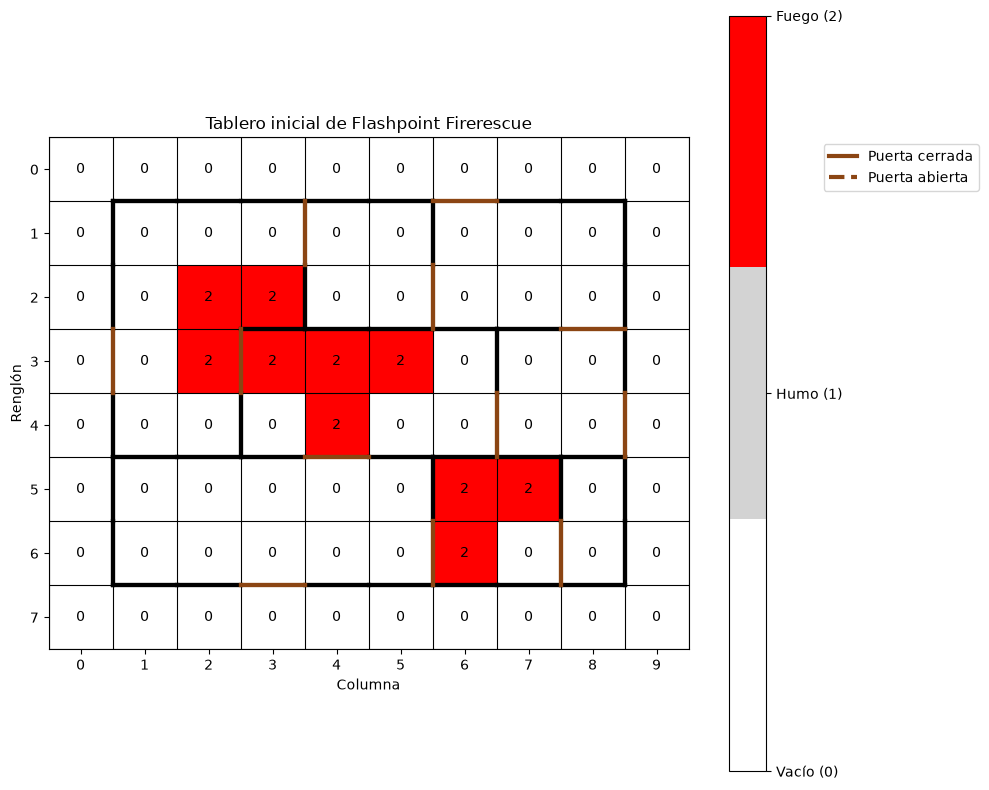

In [52]:
# Configuración inicial de dimensiones y modelo
columns = 10
rows = 8
num_players = 6

#costos de acciones (fijos)
MOVE_SPACE = 1
MOVE_SPACE_W_FIRE = 2
USE_DOOR = 1
DAMAGE_WALL = 2 #revisar daño vs romper
CARRY_VICTIM = 2
REMOVE_SMOKE = 1
FIRE_TO_SMOKE = 1
REMOVE_FIRE = 2

model = FireRescueModel(columns, rows, num_players)

# Muestra la matriz de los fuegos, igual al tablero inicial del juego
fig, axis = plt.subplots(figsize=(10, 8))

image = axis.imshow(
    model.fireCells,
    origin="upper",
    cmap=matplotlib.colors.ListedColormap(["white", "lightgray", "red"]),
    vmin=0,
    vmax=2
)

axis.set_title("Tablero inicial de Flashpoint Firerescue")
axis.set_xlabel("Columna")
axis.set_ylabel("Renglón")

axis.set_xticks(range(columns))
axis.set_yticks(range(rows))

axis.set_xticks(np.arange(-0.5, columns, 1), minor=True)
axis.set_yticks(np.arange(-0.5, rows, 1), minor=True)

axis.grid(which="minor", color="black", linewidth=0.8)
axis.tick_params(which="minor", bottom=False, left=False)

# Renderizado de números dentro de las celdas
for row in range(rows):
    for column in range(columns):
        axis.text(
            column,
            row,
            str(model.fireCells[row, column]),
            ha="center",
            va="center"
        )

# Color usado para marcar todas las puertas sobre el tablero
DOOR_COLOR = "saddlebrown"

# Dibuja las paredes intactas (valor 2) y las puertas sobre los bordes de cada celda
for row in range(model.environment.rows):
    for column in range(model.environment.columns):
        cell = model.environment.walls[row][column]
        door = model.environment.doors[row][column] #estado de las puertas de esta celda (0=no hay, 1=abierta, 2=cerrada)
        x_left, x_right = column - 0.5, column + 0.5
        y_top, y_bottom = row - 0.5, row + 0.5

        if cell.up == 2:
            axis.plot([x_left, x_right], [y_top, y_top], color="black", linewidth=3, zorder=3)
        if cell.down == 2:
            axis.plot([x_left, x_right], [y_bottom, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.left == 2:
            axis.plot([x_left, x_left], [y_top, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.right == 2:
            axis.plot([x_right, x_right], [y_top, y_bottom], color="black", linewidth=3, zorder=3)

        # Las puertas se dibujan en DOOR_COLOR; línea sólida = cerrada, punteada = abierta
        if door.up > 0:
            axis.plot([x_left, x_right], [y_top, y_top], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.up == 2 else "--")
        if door.down > 0:
            axis.plot([x_left, x_right], [y_bottom, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.down == 2 else "--")
        if door.left > 0:
            axis.plot([x_left, x_left], [y_top, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.left == 2 else "--")
        if door.right > 0:
            axis.plot([x_right, x_right], [y_top, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.right == 2 else "--")

colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Vacío (0)", "Humo (1)", "Fuego (2)"])

# Leyenda para distinguir el estado (abierta/cerrada) de las puertas dibujadas
door_legend_handles = [
    matplotlib.lines.Line2D([0], [0], color=DOOR_COLOR, linewidth=3, linestyle="-", label="Puerta cerrada"),
    matplotlib.lines.Line2D([0], [0], color=DOOR_COLOR, linewidth=3, linestyle="--", label="Puerta abierta"),
]
axis.legend(handles=door_legend_handles, loc="upper left", bbox_to_anchor=(1.2, 1))

fig.tight_layout()
plt.show()


In [53]:
# Prueba funcional del movimiento básico de un bombero
test_model = FireRescueModel(columns=10, rows=8, num_players=1)
firefighter = test_model.firefighters[0]

# Confirmar que el bombero recibe una posición inicial válida.
print(f"Posición inicial: ({firefighter.row}, {firefighter.column})")

# Asignar un objetivo válido sin calcular todavía una ruta.
assert firefighter.setObjective(0, 1)
print(f"Objetivo asignado: {firefighter.objective}")

# Moverse a una celda adyacente sin barrera y comprobar la posición en Mesa.
assert firefighter.moveTo(0, 1)
assert (firefighter.row, firefighter.column) == (0, 1)
assert firefighter.pos == (1, 0)
print(f"Movimiento válido: ({firefighter.row}, {firefighter.column})")

# Un destino que no es adyacente debe ser rechazado.
assert not firefighter.moveTo(2, 1)
print("Movimiento no adyacente rechazado")

# Avanzar hasta la entrada y comprobar que una puerta cerrada bloquea el paso.
for column in range(2, 7):
    assert firefighter.moveTo(0, column)
assert test_model.environment.getBarrier(0, 6, "down") == "closedDoor"
assert not firefighter.moveTo(1, 6)
assert (firefighter.row, firefighter.column) == (0, 6)
print("Movimiento bloqueado por puerta cerrada rechazado")

Posición inicial: (0, 0)
Objetivo asignado: (0, 1)
Movimiento válido: (0, 1)
Movimiento no adyacente rechazado
Movimiento bloqueado por puerta cerrada rechazado


In [54]:
firefighter = FirefighterAgent(model, 6, 1)

#probar función de cellMoveCost
cost, actions = firefighter.cellMoveCost(
    4,
    2,
    "right"
)

print(cost)
print(actions)

#probar función de getNeighbourMoves
neighbors = firefighter.getNeighbourMoves(6, 1)

for neighbor in neighbors:
    print(neighbor)

#probar función de obtainRoute (A*)
route, cost, actions = firefighter.obtainRoute(3, 4)

print("Route:")
print(route)

print("\nActions:")
for action in actions:
    print(action)

print("\nCost:")
print(cost)

5
[('damageWall', 4, 2, 'right', 2), ('moveSpace', 4, 2, 'right')]
(5, 1, 1, [('moveSpace', 6, 1, 'up')])
(7, 1, 5, [('damageWall', 6, 1, 'down', 2), ('moveSpace', 6, 1, 'down')])
(6, 0, 5, [('damageWall', 6, 1, 'left', 2), ('moveSpace', 6, 1, 'left')])
(6, 2, 1, [('moveSpace', 6, 1, 'right')])
Route:
[(6, 1), (5, 1), (5, 2), (5, 3), (5, 4), (4, 4), (3, 4)]

Actions:
('moveSpace', 6, 1, 'up')
('moveSpace', 5, 1, 'right')
('moveSpace', 5, 2, 'right')
('moveSpace', 5, 3, 'right')
('useDoor', 5, 4, 'up')
('moveSpaceWithFire', 5, 4, 'up')
('moveSpaceWithFire', 4, 4, 'up')

Cost:
9


In [55]:
# Verificar que el mazo de tipos de POI respeta la composición del juego (10 víctimas, 5 alarmas falsas)
# __init__ ya consume 3 cartas para los POIs iniciales, quedan 12 en el mazo
deck_check_model = FireRescueModel(columns=10, rows=8, num_players=1)
initial_types = [poi.type for poi in deck_check_model.pois]
remaining_types = [deck_check_model.drawPOIType() for _ in range(12)]
all_types = initial_types + remaining_types
assert all_types.count("victim") == 10
assert all_types.count("falseAlarm") == 5
assert deck_check_model.drawPOIType() is None
print([poi.type for poi in model.pois])
print("Mazo de POIs verificado: 10 víctimas + 5 alarmas falsas")

['victim', 'victim', 'falseAlarm']
Mazo de POIs verificado: 10 víctimas + 5 alarmas falsas


In [56]:
# Pruebas de la primera versión de la subasta de POIs
auction_model = FireRescueModel(columns=10, rows=8, num_players=3)
auction_model.pois = []
auction_model.fireCells[:, :] = 0  # aislar este escenario de los incendios iniciales por defecto
firefighters = auction_model.firefighters
firefighters[0].row, firefighters[0].column = 2, 3
firefighters[1].row, firefighters[1].column = 5, 5
firefighters[2].row, firefighters[2].column = 7, 1

poi_a = POI(2, 2, "victim", priority=10)
poi_b = POI(6, 5, "victim", priority=8)
poi_inactive = POI(0, 0, "victim", priority=100, active=False)
poi_assigned = POI(1, 1, "victim", priority=100, assigned_to=999)
auction_model.pois = [poi_a, poi_b, poi_inactive, poi_assigned]

bid_cost, bid_route, bid_actions = firefighters[0].calculateBid(poi_a)

assert bid_cost == 1
assert bid_route == [(2, 3), (2, 2)]
assert bid_actions == [
    ("moveSpace", 2, 3, "left")
]

# Un objetivo inactivo no genera oferta
assert firefighters[0].calculateBid(poi_inactive) is None

same_position_high_priority = POI(
    2, 4, "victim", priority=10
)

same_position_low_priority = POI(
    2, 4, "victim", priority=8
)

high_bid = firefighters[0].calculateBid(
    same_position_high_priority
)

low_bid = firefighters[0].calculateBid(
    same_position_low_priority
)

assert high_bid[0] == low_bid[0]

initial_positions = [(firefighter.row, firefighter.column) for firefighter in firefighters]
initial_queues = [list(firefighter.actionQueue) for firefighter in firefighters]
initial_fire = auction_model.fireCells.copy()
initial_walls = repr(auction_model.environment.walls)
initial_doors = repr(auction_model.environment.doors)
results = auction_model.runPOIAuction()

assert [result["poi"] for result in results] == [poi_a, poi_b]
assert results[0]["firefighter"] is firefighters[0]
assert results[0]["bid"] == 1
assert results[1]["firefighter"] is firefighters[1]
assert results[1]["bid"] == 1
assert poi_a.assigned_to == firefighters[0].unique_id
assert poi_b.assigned_to == firefighters[1].unique_id
assert firefighters[0].objective == (2, 2)
assert firefighters[1].objective == (6, 5)
assert firefighters[2].objective is None

# La subasta ahora también calcula la ruta A*.
assert results[0]["route"][0] == (2, 3)
assert results[0]["route"][-1] == (2, 2)

assert results[0]["routeCost"] == 1
assert results[0]["bid"] == results[0]["routeCost"]

assert firefighters[0].route == results[0]["route"]
assert firefighters[0].routeCost == results[0]["routeCost"]

# Las acciones usadas para hacer la oferta también quedan
# guardadas en el bombero ganador
assert firefighters[0].routeActions == results[0]["actions"]

assert firefighters[0].routeActions == [
    ("moveSpace", 2, 3, "left")
]

# El bombero que no ganó ningún objetivo sigue sin plan
assert firefighters[2].route is None
assert firefighters[2].routeActions is None

assert auction_model.runPOIAuction() == []
assert [(firefighter.row, firefighter.column) for firefighter in firefighters] == initial_positions
assert [list(firefighter.actionQueue) for firefighter in firefighters] == initial_queues
assert np.array_equal(auction_model.fireCells, initial_fire)
assert repr(auction_model.environment.walls) == initial_walls
assert repr(auction_model.environment.doors) == initial_doors

# Desempate: misma prioridad y distancia, gana el menor unique_id.
tie_model = FireRescueModel(columns=10, rows=8, num_players=2)
tie_model.fireCells[:, :] = 0  # aislar este escenario de los incendios iniciales por defecto
tie_model.pois = [POI(2, 2, "victim", priority=5)]
tie_model.firefighters[0].row, tie_model.firefighters[0].column = 2, 1
tie_model.firefighters[1].row, tie_model.firefighters[1].column = 1, 2
tie_result = tie_model.runPOIAuction()
assert tie_result[0]["firefighter"].unique_id == min(
    firefighter.unique_id for firefighter in tie_model.firefighters
)

# investigatePOI distingue tipo: una alarma falsa se retira, una víctima permanece activa.
false_alarm_poi = POI(3, 3, "falseAlarm", priority=1, assigned_to=firefighters[2].unique_id)
auction_model.investigatePOI(false_alarm_poi)
assert not false_alarm_poi.active
assert false_alarm_poi.assigned_to is None

auction_model.investigatePOI(poi_a)
assert poi_a.active
assert poi_a.revealed
assert poi_a.assigned_to == firefighters[0].unique_id

# Detección automática de llegada: moveTo debe investigar el POI sin llamada externa.
arrival_model = FireRescueModel(columns=10, rows=8, num_players=1)
arrival_firefighter = arrival_model.firefighters[0]
arrival_victim = POI(0, 1, "victim", priority=10)
arrival_false_alarm = POI(0, 2, "falseAlarm", priority=10)
arrival_model.pois = [arrival_victim, arrival_false_alarm]

assert not arrival_victim.revealed
assert arrival_firefighter.moveTo(0, 1)
assert arrival_victim.revealed
assert arrival_victim.active

assert not arrival_false_alarm.revealed
assert arrival_firefighter.moveTo(0, 2)
assert arrival_false_alarm.revealed
assert not arrival_false_alarm.active

# Sin POIs o sin bomberos, la ronda es una colección vacía.
empty_model = FireRescueModel(columns=10, rows=8, num_players=0)
empty_model.pois = []
assert empty_model.runPOIAuction() == []

print("Subasta de POIs: pruebas principales superadas")
print([(result["poi"].row, result["poi"].column, result["firefighter"].unique_id, result["bid"]) for result in results])

Subasta de POIs: pruebas principales superadas
[(2, 2, 1, 1), (6, 5, 2, 1)]


In [57]:
# Tarea 1: integración de objetivos víctima/incendio en la subasta
objective_model = FireRescueModel(columns=10, rows=8, num_players=2)
objective_model.pois = []
objective_model.fireCells[:, :] = 0  # controlar el escenario: solo el incendio que definamos abajo
objective_firefighters = objective_model.firefighters
objective_firefighters[0].row, objective_firefighters[0].column = 2, 3
objective_firefighters[1].row, objective_firefighters[1].column = 5, 5

# Víctima y alarma falsa vía POI; el incendio se representa directamente en fireCells (sin tocar advanceFire/explosion/shockwave).
victim_poi = POI(2, 2, "victim", priority=OBJECTIVE_PRIORITY["victim"])
false_alarm_poi = POI(1, 1, "falseAlarm", priority=OBJECTIVE_PRIORITY["falseAlarm"])
objective_model.pois = [victim_poi, false_alarm_poi]
objective_model.fireCells[6, 5] = 2  # celda con fuego real (no humo)

# Prioridad centralizada: victim > fire garantizado por el diccionario, no por valores repetidos en el código.
assert OBJECTIVE_PRIORITY["victim"] > OBJECTIVE_PRIORITY["fire"]

fire_objectives = objective_model.getActiveFireObjectives()
assert len(fire_objectives) == 1
assert (fire_objectives[0].row, fire_objectives[0].column) == (6, 5)
assert fire_objectives[0].type == "fire"
assert fire_objectives[0].priority == OBJECTIVE_PRIORITY["fire"]
assert fire_objectives[0].assigned_to is None

initial_positions = [(firefighter.row, firefighter.column) for firefighter in objective_firefighters]
initial_queues = [list(firefighter.actionQueue) for firefighter in objective_firefighters]
initial_fire_snapshot = objective_model.fireCells.copy()
initial_walls = repr(objective_model.environment.walls)
initial_doors = repr(objective_model.environment.doors)

results = objective_model.runPOIAuction()

# Prioridad: la víctima se subasta antes que el incendio (aparece primero en los resultados).
assert results[0]["poi"] is victim_poi
assert (results[1]["poi"].row, results[1]["poi"].column) == (6, 5)
assert results[1]["poi"].type == "fire"

# Asignación: tanto la víctima como el incendio reciben un bombero disponible.
assert victim_poi.assigned_to == results[0]["firefighter"].unique_id
assert results[1]["poi"].assigned_to == results[1]["firefighter"].unique_id

# 1 firefighter <-> 1 objetivo por ronda: ambos ganadores son bomberos distintos.
assert results[0]["firefighter"] is not results[1]["firefighter"]
assert {result["firefighter"].unique_id for result in results} == {
    objective_firefighters[0].unique_id,
    objective_firefighters[1].unique_id,
}

# La alarma falsa nunca compite en la subasta.
assert all(result["poi"] is not false_alarm_poi for result in results)
assert false_alarm_poi.assigned_to is None

# Un objetivo ya asignado no vuelve a entrar en la subasta.
assert objective_model.runPOIAuction() == []

# Sin efectos secundarios: posiciones, actionQueue, fuego, paredes y puertas permanecen iguales.
assert [(firefighter.row, firefighter.column) for firefighter in objective_firefighters] == initial_positions
assert [list(firefighter.actionQueue) for firefighter in objective_firefighters] == initial_queues
assert np.array_equal(objective_model.fireCells, initial_fire_snapshot)
assert repr(objective_model.environment.walls) == initial_walls
assert repr(objective_model.environment.doors) == initial_doors

print("Tarea 1 (objetivos víctima/incendio): pruebas superadas")
print([(result["poi"].type, result["poi"].row, result["poi"].column, result["firefighter"].unique_id, result["bid"]) for result in results])

Tarea 1 (objetivos víctima/incendio): pruebas superadas
[('victim', 2, 2, 1, 1), ('fire', 6, 5, 2, 2)]


In [58]:
# ============================================================
# PRUEBAS ACTUALES:
# A* -> subasta -> routeActions -> actionQueue -> ejecución
# ============================================================


# ------------------------------------------------------------
# 1. calculateBid usa el costo REAL de A*
# ------------------------------------------------------------

auction_model = FireRescueModel(columns=10, rows=8, num_players=2)
auction_model.pois = []
auction_model.fireCells[:, :] = 0

firefighters = auction_model.firefighters

firefighters[0].row, firefighters[0].column = 2, 3
firefighters[1].row, firefighters[1].column = 5, 5

poi = POI(2, 2, "victim", priority=10)
auction_model.pois = [poi]

bid_data = firefighters[0].calculateBid(poi)

assert bid_data is not None

cost, route, actions = bid_data

assert cost == 1
assert route == [
    (2, 3),
    (2, 2)
]
assert actions == [
    ("moveSpace", 2, 3, "left")
]

print("✓ calculateBid usa A* correctamente")


# ------------------------------------------------------------
# 2. La subasta conserva ruta, costo y acciones del ganador
# ------------------------------------------------------------

results = auction_model.runPOIAuction()

assert len(results) == 1

result = results[0]
winner = result["firefighter"]

assert winner is firefighters[0]

assert result["bid"] == 1
assert result["routeCost"] == 1

assert winner.route == result["route"]
assert winner.routeCost == result["routeCost"]
assert winner.routeActions == result["actions"]

assert winner.routeActions == [
    ("moveSpace", 2, 3, "left")
]

# La subasta todavía NO debe ejecutar acciones
assert list(winner.actionQueue) == []

print("✓ Subasta guarda correctamente el plan A* ganador")


# ------------------------------------------------------------
# 3. planRouteToObjective también guarda routeActions
# ------------------------------------------------------------

move_model = FireRescueModel(columns=10, rows=8, num_players=1)
move_model.pois = []
move_model.fireCells[:, :] = 0

move_firefighter = move_model.firefighters[0]

move_firefighter.row = 0
move_firefighter.column = 0

# La segunda casilla tendrá fuego
move_model.fireCells[0, 2] = 2

move_firefighter.setObjective(0, 2)

route_data = move_firefighter.planRouteToObjective()

assert route_data is not None

route, cost, actions = route_data

assert route == [
    (0, 0),
    (0, 1),
    (0, 2)
]

# 1 AP movimiento normal + 2 AP entrar a fuego
assert cost == 3

assert actions == [
    ("moveSpace", 0, 0, "right"),
    ("moveSpaceWithFire", 0, 1, "right")
]

assert move_firefighter.route == route
assert move_firefighter.routeCost == cost
assert move_firefighter.routeActions == actions

print("✓ planRouteToObjective guarda routeActions correctamente")


# ------------------------------------------------------------
# 4. generateActionQueue usa routeActions
# ------------------------------------------------------------

move_firefighter.action_points = 4

move_firefighter.generateActionQueue()

assert list(move_firefighter.actionQueue) == [
    ("moveSpace", 0, 0, "right"),
    ("moveSpaceWithFire", 0, 1, "right")
]

# Generar la cola NO debe mover ni gastar AP
assert (move_firefighter.row, move_firefighter.column) == (0, 0)
assert move_firefighter.action_points == 4

print("✓ generateActionQueue conserva las acciones de A*")


# ------------------------------------------------------------
# 5. Ejecución de moveSpace y moveSpaceWithFire
# ------------------------------------------------------------

move_firefighter.executeActionQueue()

assert (move_firefighter.row, move_firefighter.column) == (0, 2)

assert move_firefighter.action_points == 1
# 4 - 1 normal - 2 fuego = 1

assert list(move_firefighter.actionQueue) == []

print("✓ moveSpace y moveSpaceWithFire se ejecutan correctamente")


# ------------------------------------------------------------
# 6. useDoor: abrir puerta y después atravesarla
# ------------------------------------------------------------

door_model = FireRescueModel(columns=10, rows=8, num_players=1)
door_model.pois = []
door_model.fireCells[:, :] = 0

door_firefighter = door_model.firefighters[0]

# Colocarlo directamente frente a la puerta de entrada
door_model.FigthersGrid.move_agent(
    door_firefighter,
    (6, 0)   # SingleGrid usa (column, row)
)

door_firefighter.row = 0
door_firefighter.column = 6
door_firefighter.action_points = 4

assert door_model.environment.getBarrier(
    0, 6, "down"
) == "closedDoor"

# Que A* produzca el plan real
door_route_data = door_firefighter.obtainRoute(1, 6)

assert door_route_data is not None

door_route, door_cost, door_actions = door_route_data

assert door_cost == USE_DOOR + MOVE_SPACE

assert door_actions == [
    ("useDoor", 0, 6, "down"),
    ("moveSpace", 0, 6, "down")
]

door_firefighter.route = door_route
door_firefighter.routeCost = door_cost
door_firefighter.routeActions = door_actions

door_firefighter.generateActionQueue()
door_firefighter.executeActionQueue()

# La puerta debe quedar abierta
assert door_model.environment.getBarrier(
    0, 6, "down"
) == "openedDoor"

# Y el bombero debe haberla atravesado
assert (door_firefighter.row, door_firefighter.column) == (1, 6)

# Abrir = 1 AP, mover = 1 AP
assert door_firefighter.action_points == 2

assert list(door_firefighter.actionQueue) == []

print("✓ useDoor abre la puerta y permite continuar la ruta")


# ------------------------------------------------------------
# 7. damageWall: pared intacta necesita dos golpes
# ------------------------------------------------------------

wall_model = FireRescueModel(columns=10, rows=8, num_players=1)
wall_model.pois = []
wall_model.fireCells[:, :] = 0

wall_firefighter = wall_model.firefighters[0]

# Frente a una pared exterior intacta
wall_model.FigthersGrid.move_agent(
    wall_firefighter,
    (1, 0)
)

wall_firefighter.row = 0
wall_firefighter.column = 1
wall_firefighter.action_points = 4

assert getattr(
    wall_model.environment.walls[0][1],
    "down"
) == 2

# A* debe contemplar romperla y después moverse
wall_route_data = wall_firefighter.obtainRoute(1, 1)

assert wall_route_data is not None

wall_route, wall_cost, wall_actions = wall_route_data

assert wall_cost == (
    DAMAGE_WALL * 2
    + MOVE_SPACE
)

assert wall_actions == [
    ("damageWall", 0, 1, "down", 2),
    ("moveSpace", 0, 1, "down")
]

wall_firefighter.route = wall_route
wall_firefighter.routeCost = wall_cost
wall_firefighter.routeActions = wall_actions

wall_firefighter.generateActionQueue()

# Solo tiene 4 AP:
# puede dar los dos golpes, pero todavía no moverse
wall_firefighter.executeActionQueue()

assert getattr(
    wall_model.environment.walls[0][1],
    "down"
) == 0

assert (wall_firefighter.row, wall_firefighter.column) == (0, 1)

assert wall_firefighter.action_points == 0

# Debe quedar únicamente el movimiento pendiente
assert list(wall_firefighter.actionQueue) == [
    ("moveSpace", 0, 1, "down")
]

print("✓ damageWall puede consumir varios golpes sin perder la acción")


# ------------------------------------------------------------
# 8. Turno siguiente: continúa la cola después de romper pared
# ------------------------------------------------------------

wall_firefighter.endTurn()
wall_firefighter.startTurn()

assert wall_firefighter.action_points == 4

wall_firefighter.executeActionQueue()

assert (wall_firefighter.row, wall_firefighter.column) == (1, 1)

assert wall_firefighter.action_points == 3

assert list(wall_firefighter.actionQueue) == []

print("✓ La cola continúa correctamente en el turno siguiente")


print()
print("==============================================")
print("TODAS LAS PRUEBAS ACTUALES SUPERADAS ✅")
print("==============================================")

✓ calculateBid usa A* correctamente
✓ Subasta guarda correctamente el plan A* ganador
✓ planRouteToObjective guarda routeActions correctamente
✓ generateActionQueue conserva las acciones de A*
✓ moveSpace y moveSpaceWithFire se ejecutan correctamente
✓ useDoor abre la puerta y permite continuar la ruta
✓ damageWall puede consumir varios golpes sin perder la acción
✓ La cola continúa correctamente en el turno siguiente

TODAS LAS PRUEBAS ACTUALES SUPERADAS ✅


In [59]:
# Prueba de rescate automático tras descubrir una víctima
rescue_model = FireRescueModel(columns=10, rows=8, num_players=1)
rescue_model.pois = []
rescue_model.fireCells[:, :] = 0

rescue_firefighter = rescue_model.firefighters[0]
rescue_model.FigthersGrid.move_agent(rescue_firefighter, (6, 0))
rescue_firefighter.row = 0
rescue_firefighter.column = 6
rescue_firefighter.action_points = 4
rescue_model.environment.toggle_door(0, 6, "down")

victim = POI(1, 6, "victim", priority=OBJECTIVE_PRIORITY["victim"])
rescue_model.pois = [victim]

# Al llegar a la víctima se descubre, se carga y se planea automáticamente la salida.
assert rescue_firefighter.moveTo(1, 6)
assert rescue_firefighter.carryingVictim is victim
assert rescue_firefighter.rescueExit == (0, 6)
assert rescue_firefighter.objective == (0, 6)
assert rescue_firefighter.routeActions == [
    ("moveSpaceCarryingVictim", 1, 6, "up"),
]

rescue_firefighter.generateActionQueue()
rescue_firefighter.executeActionQueue()

assert (rescue_firefighter.row, rescue_firefighter.column) == (0, 6)
assert rescue_firefighter.action_points == 2
assert victim.rescued
assert not victim.active
assert rescue_firefighter.carryingVictim is None
assert rescue_model.getActivePOIs() == []
assert list(rescue_firefighter.actionQueue) == []

print("Rescate automático: ruta, traslado y retirada de víctima verificados")

Rescate automático: ruta, traslado y retirada de víctima verificados


In [60]:
# Pruebas de extinción de humo y fuego
extinguish_model = FireRescueModel(columns=10, rows=8, num_players=1)
extinguish_model.pois = [POI(2, 2, "victim", priority=10)]
extinguish_model.fireCells[:, :] = 0
extinguish_firefighter = extinguish_model.firefighters[0]
extinguish_model.FigthersGrid.move_agent(extinguish_firefighter, (4, 3))
extinguish_firefighter.row = 3
extinguish_firefighter.column = 4

initial_position = (extinguish_firefighter.row, extinguish_firefighter.column)
initial_walls = repr(extinguish_model.environment.walls)
initial_doors = repr(extinguish_model.environment.doors)
initial_pois = repr(extinguish_model.pois)

# Humo -> vacío por 1 AP.
extinguish_model.fireCells[3, 4] = 1
extinguish_firefighter.action_points = 4
assert extinguish_firefighter.extinguishFire(3, 4)
assert extinguish_model.fireCells[3, 4] == 0
assert extinguish_firefighter.action_points == 3

# Fuego -> humo por 1 AP.
extinguish_model.fireCells[3, 5] = 2
assert extinguish_firefighter.extinguishFire(3, 5)
assert extinguish_model.fireCells[3, 5] == 1
assert extinguish_firefighter.action_points == 2

# Fuego -> vacío por 2 AP.
extinguish_model.fireCells[3, 5] = 2

assert extinguish_firefighter.extinguishFire(3,5,removeFire=True)
assert extinguish_model.fireCells[3, 5] == 0
assert extinguish_firefighter.action_points == 0

# Prueba: No se puede extinguir a través de una pared.
extinguish_firefighter.action_points = 2
extinguish_model.fireCells[2, 4] = 2

assert (extinguish_model.environment.getBarrier(3,4,"up")== "wall")
assert not extinguish_firefighter.extinguishFire(2,4,removeFire=True)
# El fuego sigue ahí y no gastó AP.
assert extinguish_model.fireCells[2, 4] == 2
assert extinguish_firefighter.action_points == 2

# Una celda vacía, remota o con AP insuficientes no cambia estado ni consume AP.
extinguish_firefighter.action_points = 2
empty_snapshot = extinguish_model.fireCells.copy()
assert not extinguish_firefighter.extinguishFire(3, 4)
assert not extinguish_firefighter.extinguishFire(6, 6)
assert np.array_equal(extinguish_model.fireCells, empty_snapshot)
assert extinguish_firefighter.action_points == 2

extinguish_model.fireCells[3, 5] = 2
extinguish_firefighter.action_points = 1
fire_snapshot = extinguish_model.fireCells.copy()
assert not extinguish_firefighter.extinguishFire(3, 5, removeFire=True)
assert np.array_equal(extinguish_model.fireCells, fire_snapshot)
assert extinguish_firefighter.action_points == 1

# EXTINGUISH conserva el formato de alto nivel y se ejecuta dentro de actionQueue.
extinguish_model.fireCells[3, 4] = 1
extinguish_model.fireCells[3, 5] = 2
extinguish_firefighter.action_points = 4
extinguish_firefighter.actionQueue = deque([
    ("EXTINGUISH", 3, 4),
    ("EXTINGUISH", 3, 5, True),
])
extinguish_firefighter.executeActionQueue()
assert extinguish_model.fireCells[3, 4] == 0
assert extinguish_model.fireCells[3, 5] == 0
assert extinguish_firefighter.action_points == 1
assert list(extinguish_firefighter.actionQueue) == []

# Si faltan AP, EXTINGUISH y las acciones posteriores quedan pendientes.
extinguish_model.fireCells[3, 5] = 2
extinguish_firefighter.action_points = 1
extinguish_firefighter.actionQueue = deque([
    ("EXTINGUISH", 3, 5, True),
    ("moveSpace", 3, 4, "left"),
])
pending_fire_snapshot = extinguish_model.fireCells.copy()
extinguish_firefighter.executeActionQueue()
assert np.array_equal(extinguish_model.fireCells, pending_fire_snapshot)
assert extinguish_firefighter.action_points == 1
assert list(extinguish_firefighter.actionQueue) == [
    ("EXTINGUISH", 3, 5, True),
    ("moveSpace", 3, 4, "left"),
]
assert (extinguish_firefighter.row, extinguish_firefighter.column) == initial_position

# La extinción no afecta paredes, puertas, POIs ni la posición del bombero.
assert repr(extinguish_model.environment.walls) == initial_walls
assert repr(extinguish_model.environment.doors) == initial_doors
assert repr(extinguish_model.pois) == initial_pois

# FireObjective se actualiza únicamente al sincronizarse después del cambio en fireCells.
extinguish_model.fireCells[2, 4] = 0 #limpiar el fuego usado en la prueba anterior de la pared
extinguish_model.fireCells[3, 5] = 2
assert {(objective.row, objective.column) for objective in extinguish_model.getActiveFireObjectives()} == {(3, 5)}
extinguish_firefighter.action_points = 2
assert extinguish_firefighter.extinguishFire(3, 5, removeFire=True)
assert extinguish_model.fireCells[3, 5] == 0
assert extinguish_model.fireObjectives
assert extinguish_model.getActiveFireObjectives() == []
assert extinguish_model.fireObjectives == {}

print("Extinción: transiciones, AP, cola y sincronización de incendios verificados")

Extinción: transiciones, AP, cola y sincronización de incendios verificados


In [63]:
# Pruebas corregidas del ciclo de re-subasta
cycle_model = FireRescueModel(columns=10, rows=8, num_players=1)
cycle_model.pois = []
cycle_model.fireCells[:, :] = 0
cycle_model.fireCells[5, 5] = 2

cycle_firefighter = cycle_model.firefighters[0]
cycle_firefighter.row = 3
cycle_firefighter.column = 4
cycle_firefighter.action_points = 4

cycle_results = cycle_model.runObjectiveCycle()
assert len(cycle_results) == 1
assert cycle_firefighter.objective == (5, 5)
assert cycle_firefighter.route is not None
assert cycle_firefighter.routeCost == cycle_results[0]["routeCost"]
assert list(cycle_firefighter.actionQueue) == cycle_firefighter.routeActions

# La ruta termina en la casilla de ataque; la extinción apunta al fuego como acción aparte.
attack_position = cycle_firefighter.route[-1]
assert abs(attack_position[0] - 5) + abs(attack_position[1] - 5) == 1
assert cycle_firefighter.routeActions[-1] == ("EXTINGUISH", 5, 5, True)
assert (5, 5) not in cycle_firefighter.route

# Un objetivo activo conserva su plan y su cola en otra ronda.
previous_route = list(cycle_firefighter.route)
previous_queue = list(cycle_firefighter.actionQueue)
cycle_model.runObjectiveCycle()
assert cycle_firefighter.objective == (5, 5)
assert cycle_firefighter.route == previous_route
assert list(cycle_firefighter.actionQueue) == previous_queue

# Simular que el bombero llegó a la casilla de ataque y extinguir el fuego.
cycle_model.FigthersGrid.move_agent(
    cycle_firefighter,
    (attack_position[1], attack_position[0])
)
cycle_firefighter.row, cycle_firefighter.column = attack_position
cycle_firefighter.action_points = 2
assert cycle_firefighter.extinguishFire(5, 5, removeFire=True)
cycle_model.runObjectiveCycle()
assert cycle_firefighter.objective is None
assert cycle_firefighter.route is None
assert cycle_firefighter.routeActions is None
assert list(cycle_firefighter.actionQueue) == []

# Un objetivo nuevo puede ser asignado en la siguiente ronda.
cycle_model.fireCells[2, 2] = 2
new_results = cycle_model.runObjectiveCycle()
assert len(new_results) == 1
assert cycle_firefighter.objective == (2, 2)
assert cycle_firefighter.route is not None
assert list(cycle_firefighter.actionQueue) == cycle_firefighter.routeActions

# El ciclo no altera AP ni posición al planificar.
position_before = (cycle_firefighter.row, cycle_firefighter.column)
ap_before = cycle_firefighter.action_points
saved_ap_before = cycle_firefighter.saved_action_points
cycle_model.runObjectiveCycle()
assert (cycle_firefighter.row, cycle_firefighter.column) == position_before
assert cycle_firefighter.action_points == ap_before
assert cycle_firefighter.saved_action_points == saved_ap_before

print("Ciclo de re-subasta: ruta de ataque, conservación, liberación y reasignación verificados")

Ciclo de re-subasta: ruta de ataque, conservación, liberación y reasignación verificados
